In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


## Predicting Insurance Claim Amounts (Regression)

### Objective: 

Estimate the medical insurance claim amount (charges) based on personal data like age, BMI, and smoking status.

### Workflow:

Exploratory Data Analysis (EDA)

Encoding categorical variables (smoker, sex, region)

Training a Linear Regression model

Evaluation using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_ins = pd.read_csv('/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv')

# Quick look
print(df_ins.info())
df_ins.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1. Visualizing Key Impact Factors

Before modeling, we need to see how features like Age, BMI, and Smoker status correlate with the charges.

/tmp/ipykernel_57/4110018366.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ins, x='smoker', y='charges', palette='Set2')


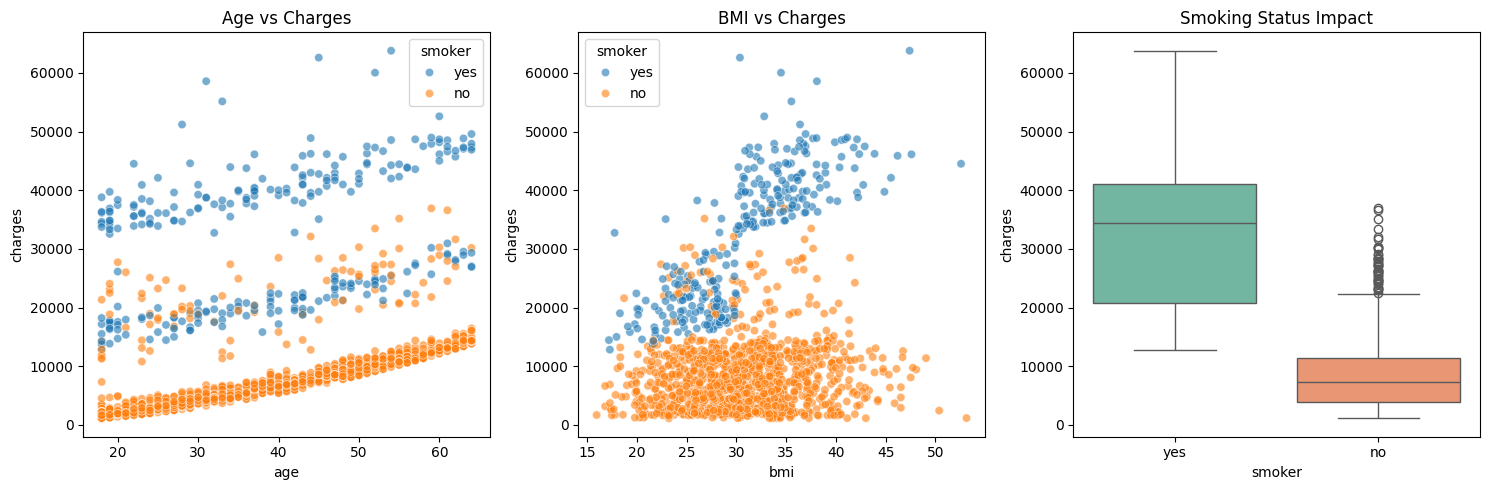

In [4]:
plt.figure(figsize=(15, 5))

# Age vs Charges
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_ins, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Age vs Charges')

# BMI vs Charges
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_ins, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title('BMI vs Charges')

# Smoker status vs Charges
plt.subplot(1, 3, 3)
sns.boxplot(data=df_ins, x='smoker', y='charges', palette='Set2')
plt.title('Smoking Status Impact')

plt.tight_layout()
plt.show()

### 2. Preprocessing & Modeling

Linear Regression cannot handle text. We convert smoker and sex into binary values and use One-Hot Encoding for the region.

In [5]:
# Encoding
df_ins['smoker'] = df_ins['smoker'].map({'yes': 1, 'no': 0})
df_ins['sex'] = df_ins['sex'].map({'male': 1, 'female': 0})
df_ins = pd.get_dummies(df_ins, columns=['region'], drop_first=True)

# Features and Target
X = df_ins.drop('charges', axis=1)
y = df_ins['charges']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predictions
y_pred = reg_model.predict(X_test)

### 3. Evaluation Metrics

Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28


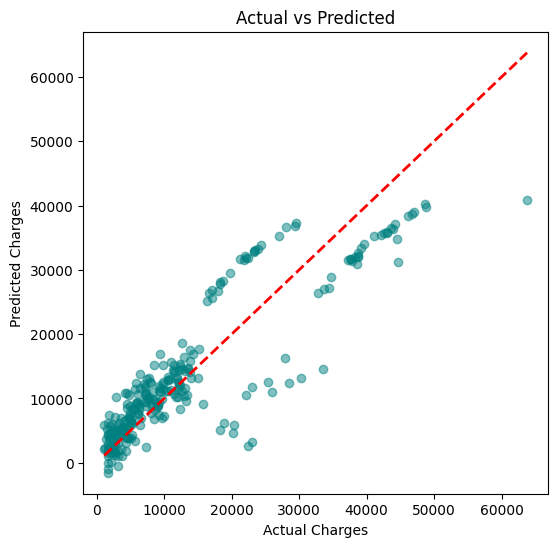

In [6]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

# Visualize Accuracy
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted')
plt.show()